<a href="https://colab.research.google.com/github/pulseq/ISMRM-Virtual-Meeting--February-24-26-2026/blob/main/tutorials/day1_basicPulseqTutorial/Jupyter_Notebooks/s03_gre1d2gre2d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# from 1D GRE to 2D GRE
**Exercise**:   
This exercise starts from 1D GRE. Now extend 1D GRE to 2D GRE by inserting the phase-encoding gradient.

In [1]:
#@title 2D GRE in a brain phantom - environment setup
!pip show pypulseq || pip install pypulseq==1.4.2
import pypulseq as pp

# for MRzero simulation
!pip show MRzeroCore || pip install MRzeroCore
!wget https://github.com/MRsources/MRzero-Core/raw/main/documentation/playground_mr0/util.py &> /dev/null
!wget https://github.com/MRsources/MRzero-Core/raw/main/documentation/playground_mr0/numerical_brain_cropped.mat &> /dev/null
import MRzeroCore as mr0

import numpy as np
from matplotlib import pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.0/278.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.1/254.1 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.7/108.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.3/377.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.0/475.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 14.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Timing check passed successfully


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


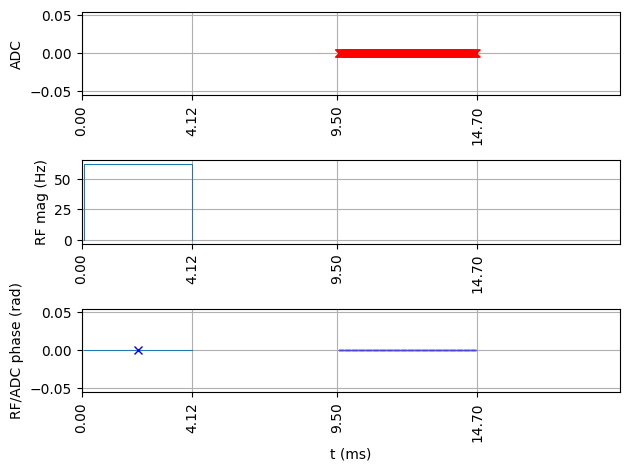

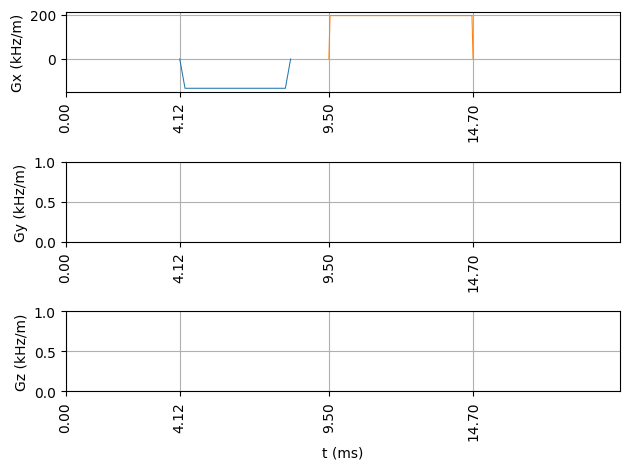

'12440d1222c92d8025afc7682a1250df'

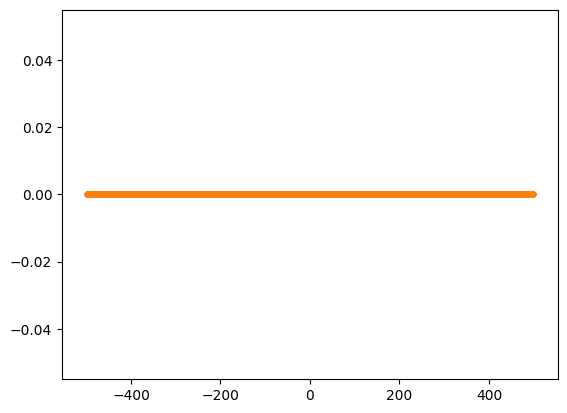

In [2]:
#@title 2D GRE in a brain phantom - sequence

# Define number of ADC samples
fov = 256e-3
Nread = 256
Nphase=Nread
TE = 10e-3 # echo time
TR = 10 # repetition time

# Setup scanner limits
sys = pp.Opts(
    max_grad=28, grad_unit='mT/m', max_slew=150, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6,
    adc_dead_time=20e-6, grad_raster_time=10e-6)

# Setup sequence object
seq = pp.Sequence(sys)

# Define RF event, 90-deg hard pulse for excitation
rf_ex = pp.make_block_pulse(flip_angle=90*np.pi/180, duration=4e-3, phase_offset=0*np.pi/180, delay=10e-6, system=sys)

# Define ADC event
adc = pp.make_adc(num_samples=Nread, duration=5.12e-3, phase_offset=0*np.pi/180, delay=10e-6, system=sys)

# Define readout gradients
deltak = 1/fov
gx = pp.make_trapezoid(channel='x', flat_area=Nread*deltak, flat_time=adc.dwell*adc.num_samples, system=sys) # readout gradient
adc.delay = gx.rise_time
gx_pre = pp.make_trapezoid(channel='x', area=-gx.area/2, duration=4e-3, system=sys) # readout pre-phaser

# Calculate timing
delayTE = TE - rf_ex.shape_dur/2 - rf_ex.ringdown_time - pp.calc_duration(gx)/2
delayTR = TR - pp.calc_duration(rf_ex) - delayTE - pp.calc_duration(gx)

# ======
# CONSTRUCT SEQUENCE
# ======
for i in range(0, Nphase):
  seq.add_block(rf_ex)
  gy = pp.make_trapezoid(channel='y',area=(i-Nphase/2)*deltak, duration=pp.calc_duration(gx_pre),system=sys)
  seq.add_block(gx_pre, pp.make_delay(delayTE))
  seq.add_block(gx, adc)
  seq.add_block(pp.make_delay(delayTR))

# Check timing
(ok, error_report) = seq.check_timing()  # Check whether the timing of the sequence is correct
if ok:
    print("Timing check passed successfully")
else:
    print("Timing check failed. Error listing follows:")
    [print(e) for e in error_report]

# Plot sequence diagram
time_range = [0, 0.02]
seq.plot(time_range=time_range, time_disp='ms', show_blocks=True)

# Plot k-space trajectory
k_traj_adc, k_traj, t_excitation, t_refocusing, t_adc = seq.calculate_kspace()

plt.figure()
plt.plot(k_traj[0],k_traj[1])
plt.plot(k_traj_adc[0],k_traj_adc[1],'.')

# Prepare the sequence output for the scanner
seq.set_definition('Name', 'fid')
seq.write('s03_gre1d2gre2d.seq')

VoxelGridPhantom
size = tensor([0.2000, 0.2000, 0.0080])


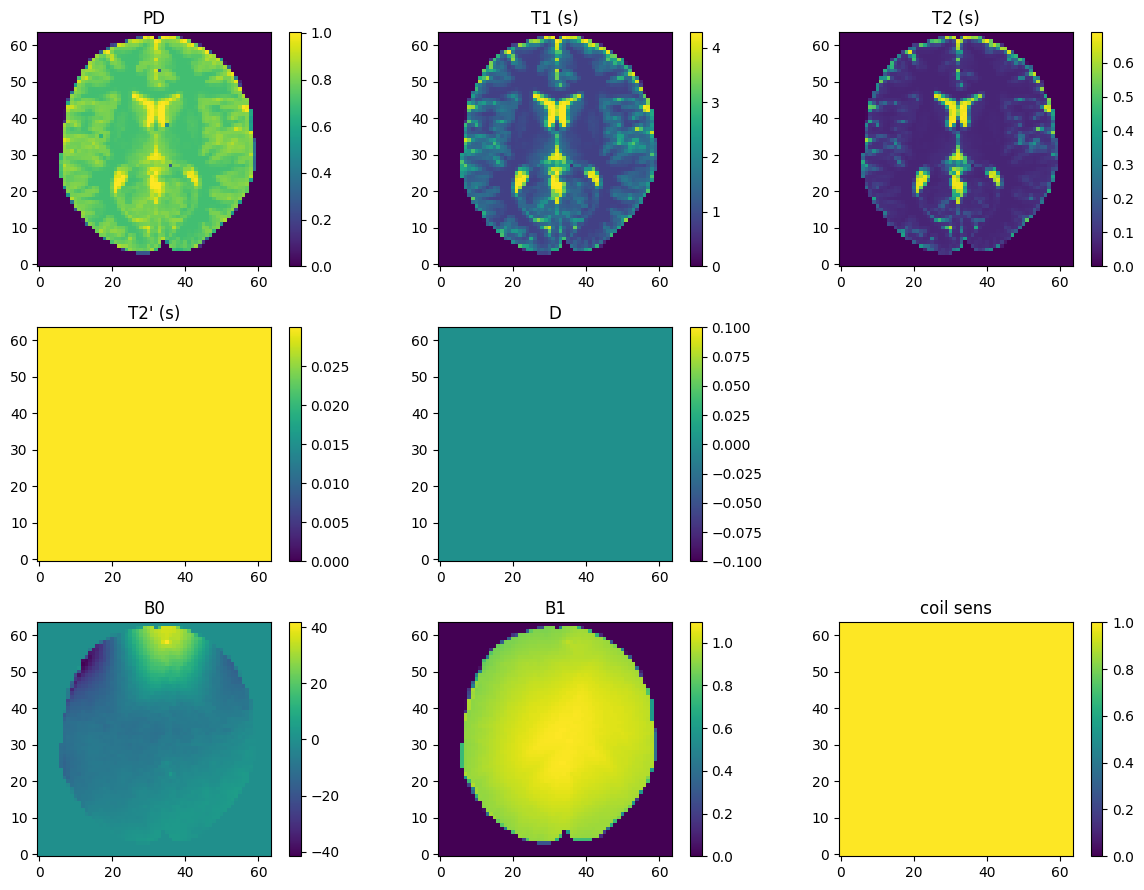

In [3]:
#@title 2D GRE in a brain phantom - simulation
dB0 = 0
sz = [64, 64]
# %% S4: SETUP SPIN SYSTEM/object on which we can run the MR sequence external.seq from above
# (i) load a phantom object from file
obj_p = mr0.VoxelGridPhantom.load_mat('numerical_brain_cropped.mat')
obj_p = obj_p.interpolate(sz[0], sz[1], 1)
# Manipulate loaded data
obj_p.T2dash[:] = 30e-3
obj_p.D *= 0
obj_p.B0 *= 1    # alter the B0 inhomogeneity
# Store PD and B0 for comparison
PD = obj_p.PD
B0 = obj_p.B0
# Manipulate loaded data
obj_p.B0+=dB0
obj_p.D*=0
obj_p.plot()
# Convert Phantom into simulation data
obj_p=obj_p.build()

# %% SIMULATE  the external.seq file and add acquired signal to ADC plot
# Read in the sequence
seq0 = mr0.Sequence.import_file("s03_gre1d2gre2d.seq")
#seq0.plot_kspace_trajectory()
# Simulate the sequence
graph=mr0.compute_graph(seq0, obj_p, 200, 1e-3)
signal=mr0.execute_graph(graph, seq0, obj_p, print_progress=False)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:48: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return conv.wrap(result, to_scalar=False)
/tmp/ipython-input-3446143521.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.abs(kspace)); plt.axis('off')


(np.float64(-0.5), np.float64(63.5), np.float64(-0.5), np.float64(63.5))

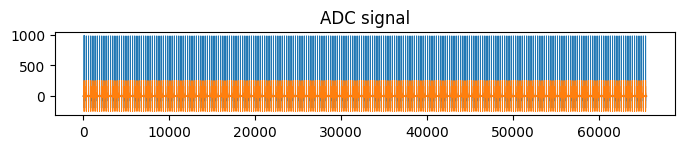

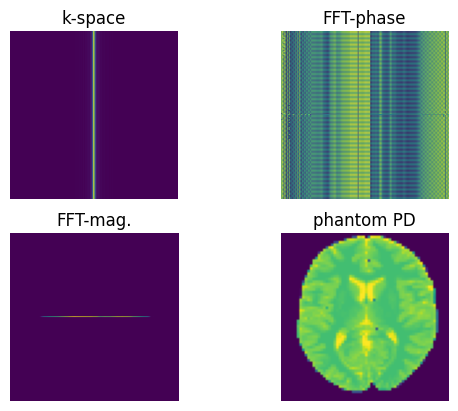

In [4]:
#@title 2D GRE in a brain phantom - reconstruction
# 2D FFT
def fft_2d(x):
    return np.fft.fftshift(np.fft.fftn(np.fft.ifftshift(x)))

kspace = np.reshape(signal, (Nphase, Nread))
im = fft_2d(kspace)

fig = plt.figure(figsize=(8, 5))
plt.subplot(411)
plt.title('ADC signal')
plt.plot(np.real(signal), label='real')
plt.plot(np.imag(signal), label='imag')

plt.figure()
plt.subplot(221)
plt.title('k-space')
plt.imshow(np.abs(kspace)); plt.axis('off')
plt.subplot(222)
plt.title('FFT-phase')
plt.imshow(np.angle(im), vmin=-np.pi, vmax=np.pi, origin="lower"); plt.axis('off')
plt.subplot(223)
plt.title('FFT-mag.')
plt.imshow(np.abs(im), origin="lower"); plt.axis('off')
plt.subplot(224)
plt.title('phantom PD')
plt.imshow(PD.squeeze().T, origin="lower"); plt.axis('off')